<a href="https://colab.research.google.com/github/jiteshnaagar510-ship-it/Colab-file/blob/main/Q1107248_JITESH_NAAGAR_INTRO_IN_AI_FINAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


**Task One** **(EXPLORATORY DATA ANALYSIS (EDA))**

**Import Libraries**

1.  **Initial Data Loading and Inspection:**



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc, RocCurveDisplay

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

import shap
!pip install lime
import lime
import lime.lime_tabular

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/drive/MyDrive/lung_disease_v1 (1).csv')

df.head()
df.shape
df.columns
df.dtypes
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 33 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   patient_id                 12000 non-null  int64  
 1   age                        12000 non-null  int64  
 2   sex                        12000 non-null  object 
 3   bmi                        12000 non-null  float64
 4   smoking_status             12000 non-null  object 
 5   pack_years                 12000 non-null  float64
 6   pm25_exposure              12000 non-null  float64
 7   occupation                 12000 non-null  object 
 8   family_history             4824 non-null   object 
 9   cough                      12000 non-null  int64  
 10  dyspnea                    12000 non-null  int64  
 11  wheeze                     12000 non-null  int64  
 12  chest_pain                 12000 non-null  int64  
 13  fever                      12000 non-null  int

2. **Target Variable Investigation:**

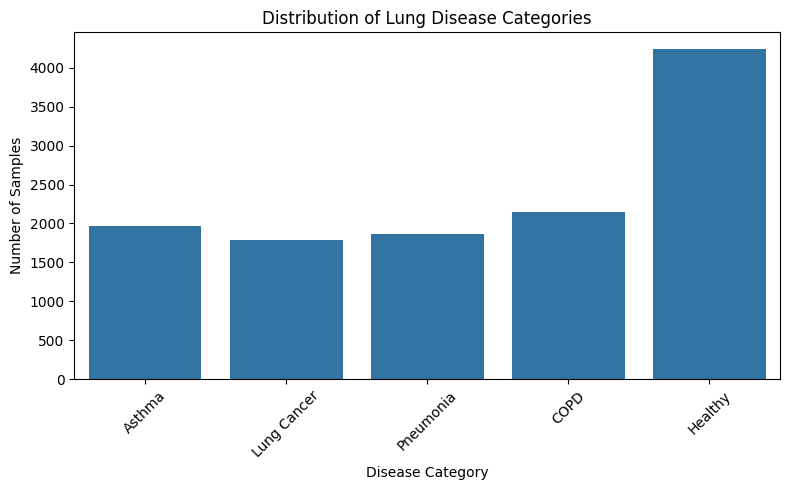

2.382369455362156

In [ ]:
target_column = 'disease_type'
df[target_column].value_counts()
df[target_column].value_counts(normalize=True) * 100

plt.figure(figsize=(8,5))
sns.countplot(x=target_column, data=df)
plt.title("Distribution of Lung Disease Categories")
plt.xlabel("Disease Category")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

imbalance_ratio = df[target_column].value_counts().max() / df[target_column].value_counts().min()
imbalance_ratio

3. **Descriptive Statistics:**

In [ ]:
df.describe()
numerical_features = df.select_dtypes(include=['int64', 'float64'])

mean_values = numerical_features.mean()
median_values = numerical_features.median()
std_values = numerical_features.std()
min_values = numerical_features.min()
max_values = numerical_features.max()

summary_stats = pd.DataFrame({
    'Mean': mean_values,
    'Median': median_values,
    'Std Dev': std_values,
    'Min': min_values,
    'Max': max_values
})

summary_stats
high_variability = summary_stats.sort_values(by='Std Dev', ascending=False)
high_variability.head()


,Mean,Median,Std Dev,Min,Max
patient_id,6000.500000,6000.5,3464.245950,1.0,12000.0
sixmwd_m,403.809167,405.0,109.520138,-29.0,816.0
crp_mg_L,20.793150,10.3,30.606319,0.0,218.6
fev1_pct_pred,83.805633,85.1,18.773718,20.0,140.0
dlco_pct_pred,81.511558,82.4,17.630906,20.0,139.5


4. **Visualization of Numerical Features:**

**Histograms , Boxplots , Distribution Plots**

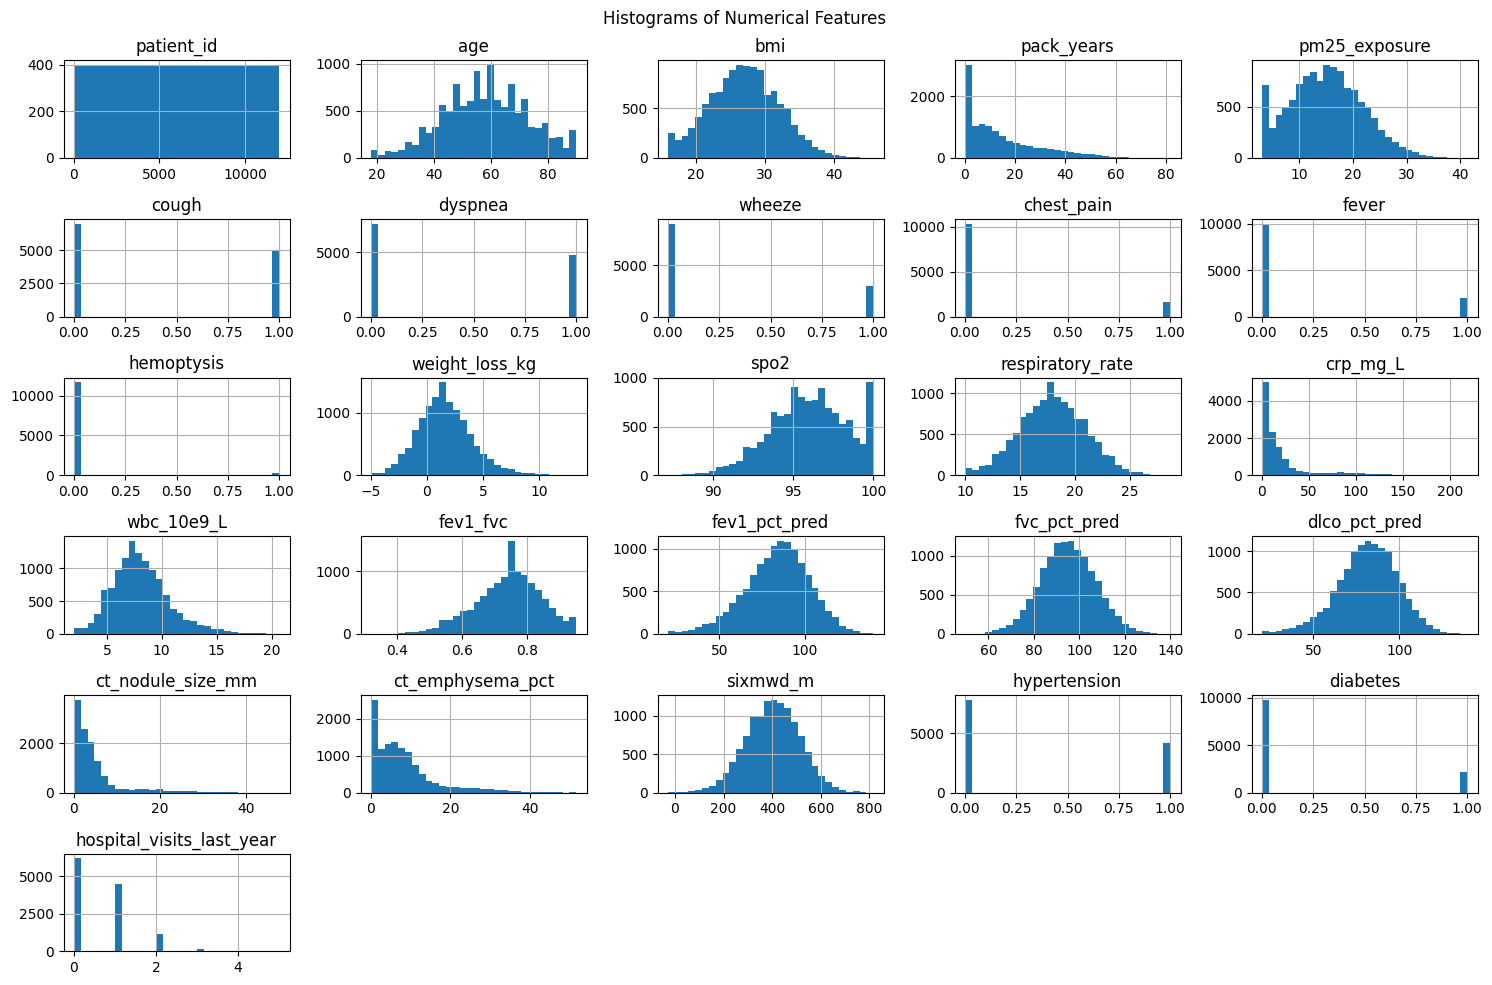

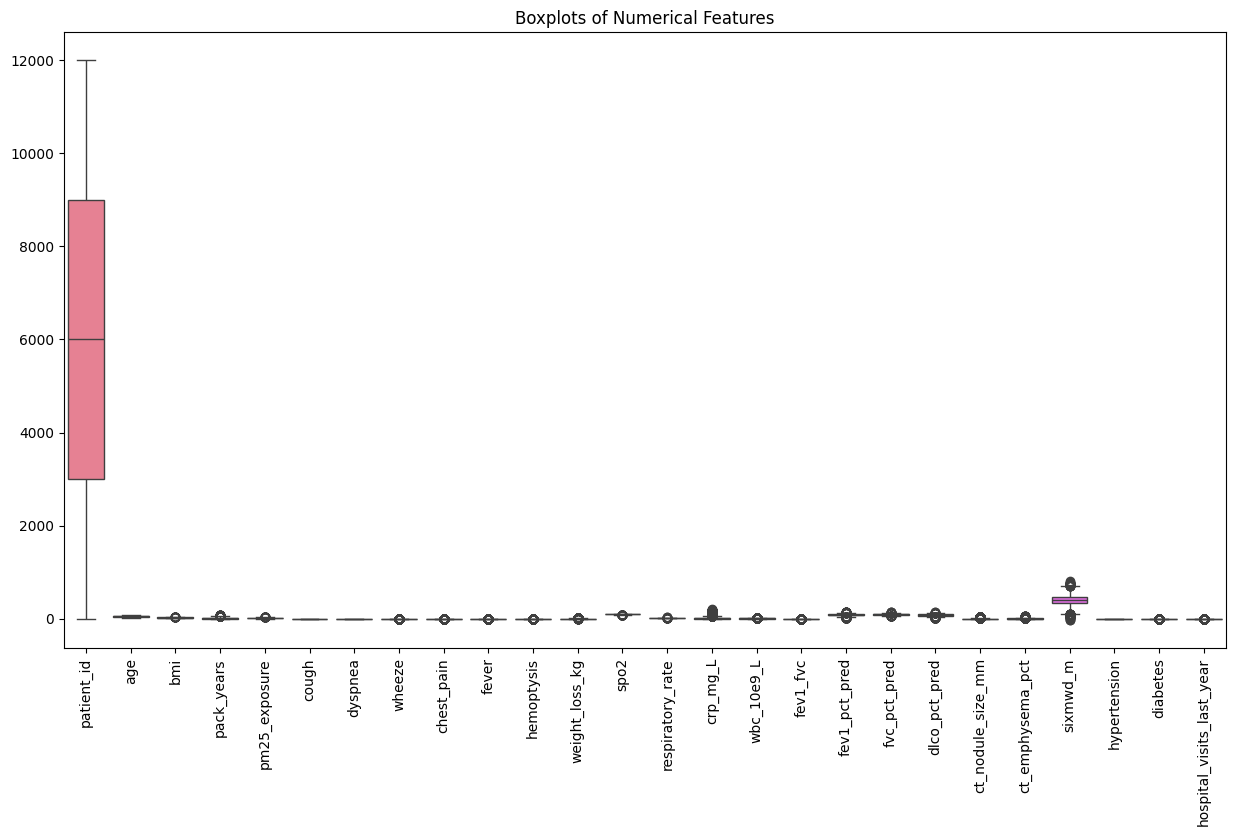

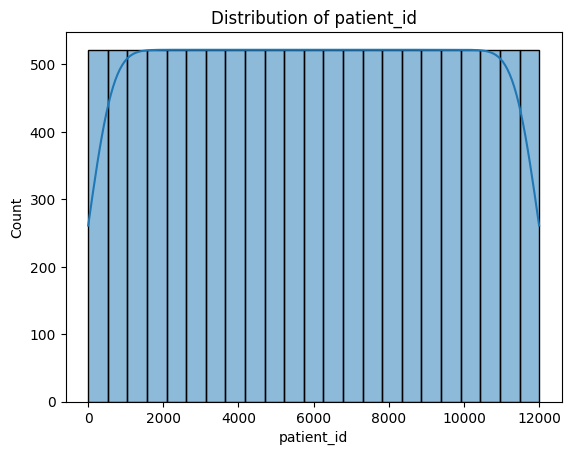

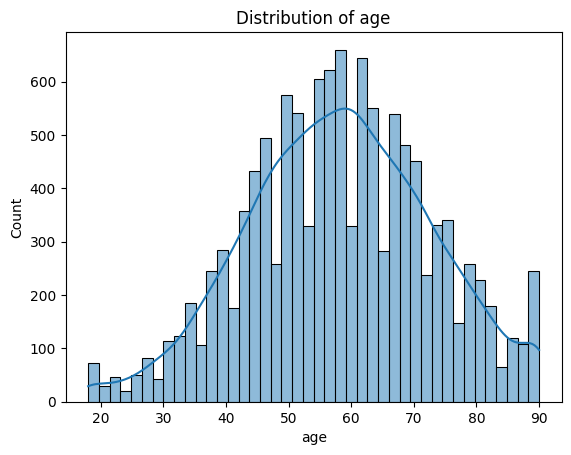

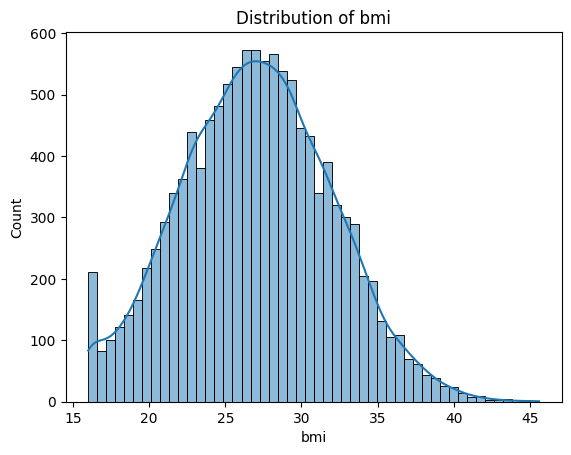

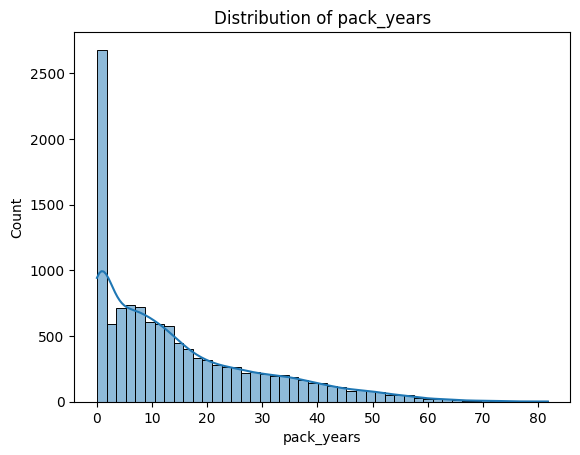

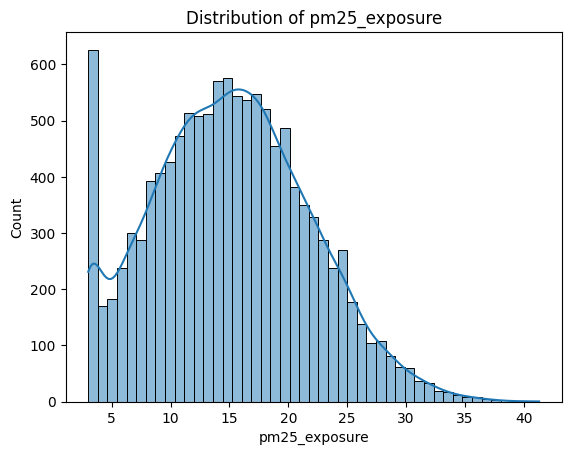

In [ ]:
numerical_features.hist(figsize=(15,10), bins=30)
plt.suptitle("Histograms of Numerical Features")
plt.tight_layout()
plt.show()

plt.figure(figsize=(15,8))
sns.boxplot(data=numerical_features)
plt.xticks(rotation=90)
plt.title("Boxplots of Numerical Features")
plt.show()

for col in numerical_features.columns[:5]:  # limit for readability
    plt.figure()
    sns.histplot(numerical_features[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()


5. **Correlation Analysis:**

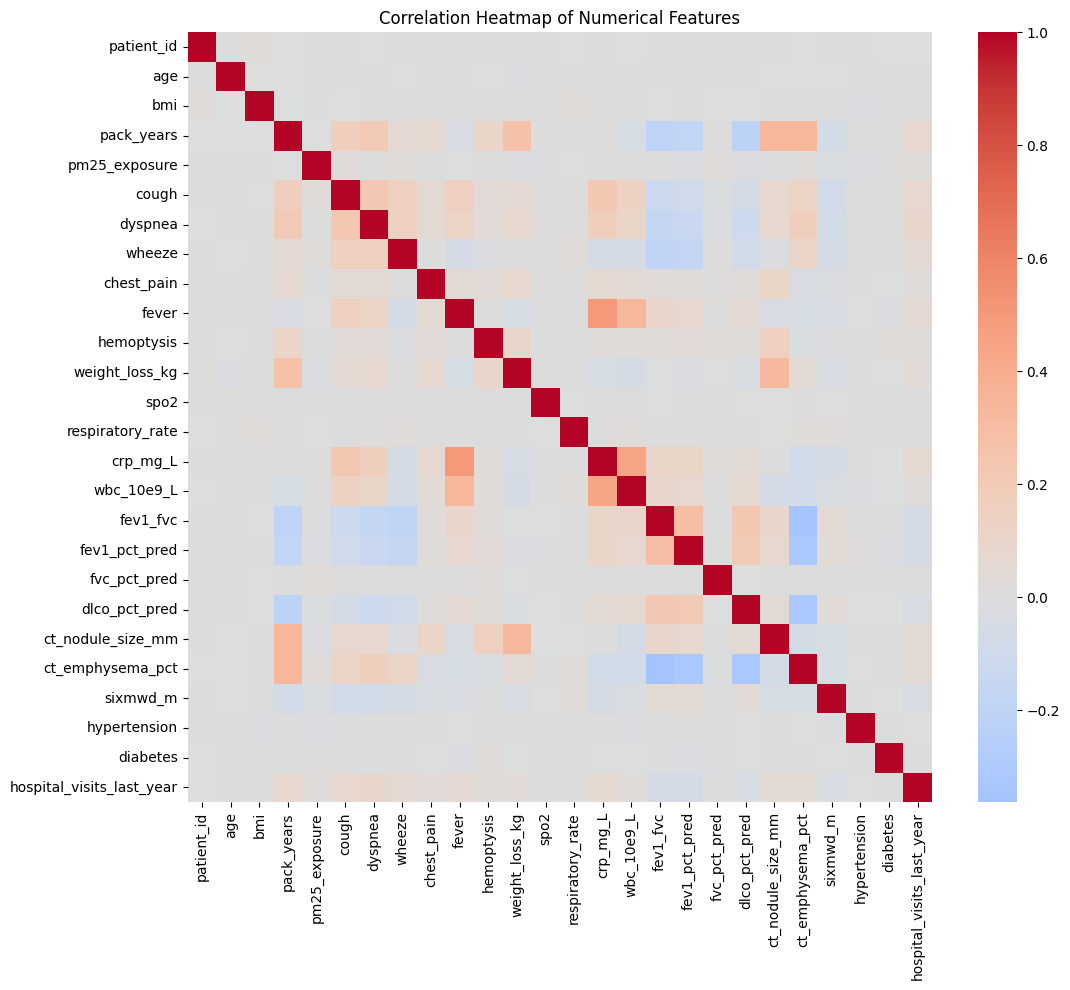

,patient_id,age,bmi,pack_years,pm25_exposure,cough,dyspnea,wheeze,chest_pain,fever,...,fev1_fvc,fev1_pct_pred,fvc_pct_pred,dlco_pct_pred,ct_nodule_size_mm,ct_emphysema_pct,sixmwd_m,hypertension,diabetes,hospital_visits_last_year
patient_id,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bmi,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pack_years,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pm25_exposure,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cough,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dyspnea,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
wheeze,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
chest_pain,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fever,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
correlation_matrix = numerical_features.corr()
plt.figure(figsize=(12,10))
sns.heatmap(correlation_matrix, cmap='coolwarm', center=0)
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

high_corr = correlation_matrix[(correlation_matrix > 0.7) | (correlation_matrix < -0.7)]
high_corr.dropna(how='all')



6. **Feature Target Relationship:**

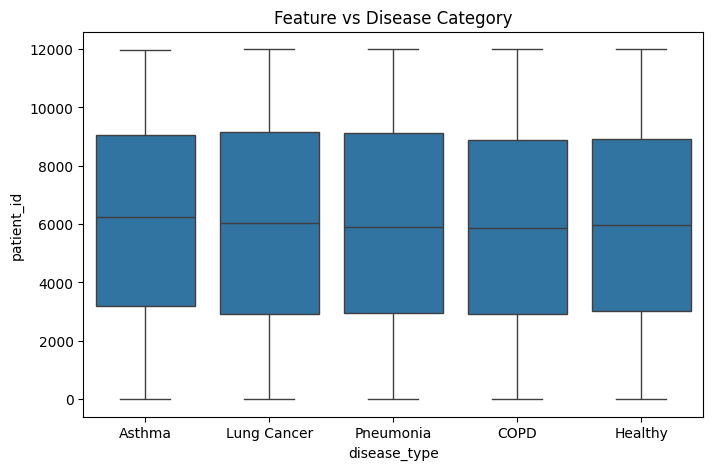

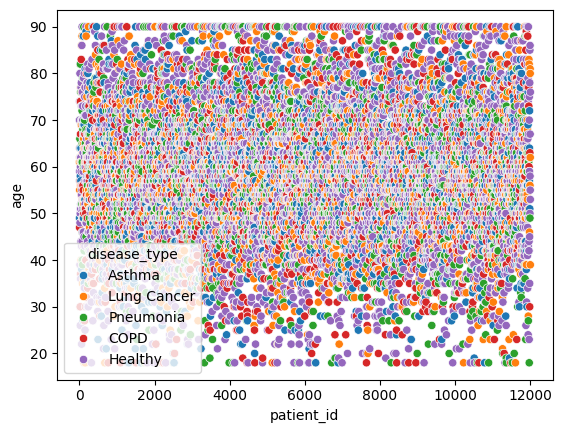

In [ ]:
df.groupby(target_column)[numerical_features.columns].mean()
plt.figure(figsize=(8,5))
sns.boxplot(x=target_column, y=numerical_features.columns[0], data=df)
plt.title("Feature vs Disease Category")
plt.show()

sns.scatterplot(x=numerical_features.columns[0],
                y=numerical_features.columns[1],
                hue=target_column,
                data=df)
plt.show()

**TASK TWO (DATA PREPARATION)**
1. **Missing Values:**

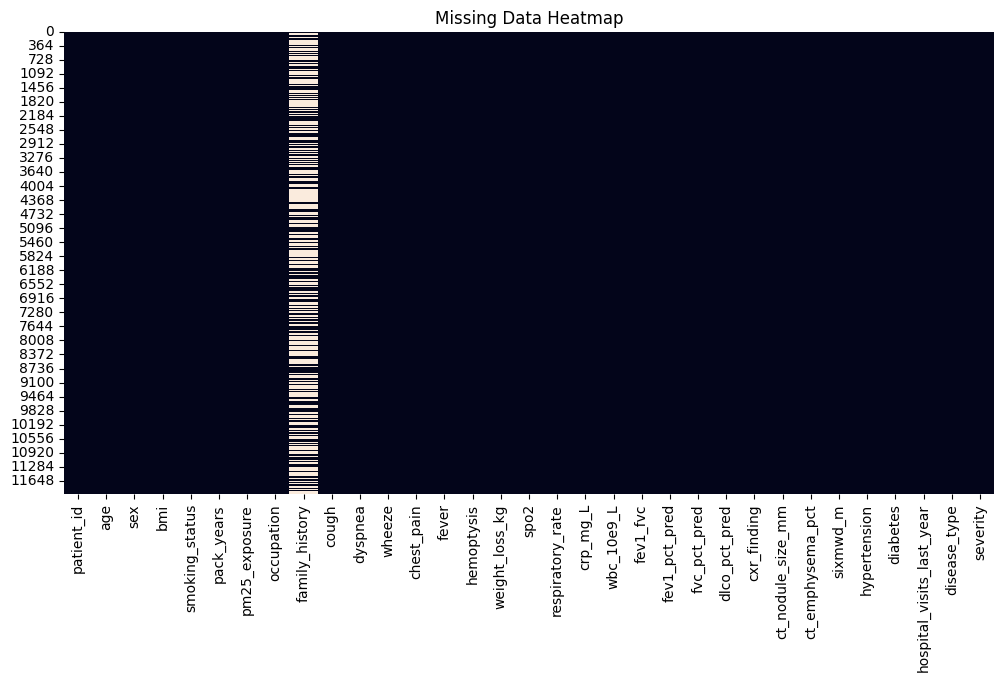

In [ ]:
df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_percentage.sort_values(ascending=False)

plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Data Heatmap")
plt.show()



2. **Missing Values Handling:**

In [ ]:
df.shape
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include='object').columns
from sklearn.impute import SimpleImputer

num_imputer = SimpleImputer(strategy='mean')
df[numerical_cols] = num_imputer.fit_transform(df[numerical_cols])

cat_imputer = SimpleImputer(strategy='most_frequent')
df[categorical_cols] = cat_imputer.fit_transform(df[categorical_cols])
df.shape
df.isnull().sum()



,0
patient_id,0
age,0
sex,0
bmi,0
smoking_status,0
pack_years,0
pm25_exposure,0
occupation,0
family_history,0
cough,0


3. **Categorical Variable Coding:**

In [ ]:
categorical_cols
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)
df_encoded.head()
df_encoded.shape


(12000, 50)

4. **Target Variable Coding:**

In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
df_encoded['disease_encoded'] = label_encoder.fit_transform(df['disease_type'])

label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
label_mapping
df_encoded['disease_encoded'].value_counts()

,count
disease_encoded,
2,4243
1,2147
0,1968
4,1861
3,1781


5. **Feature Scaling:**

In [ ]:
features = df_encoded.drop(['disease_encoded'], axis=1)
target = df_encoded['disease_encoded']
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.2, random_state=42, stratify=target
)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
pd.DataFrame(X_train).describe().loc[['mean','std','min','max']]
pd.DataFrame(X_train_scaled).describe().loc[['mean','std','min','max']]

,0,1,2,3,4,5,6,7,8,9,...,40,41,42,43,44,45,46,47,48,49
mean,3.700743e-18,-8.641236e-17,6.117329e-16,-1.776357e-17,1.014004e-16,-5.902686e-17,-7.179442e-17,9.621933e-18,1.480297e-17,-2.701543e-17,...,-2.349972e-17,-6.476301e-18,-1.286008e-16,-1.480297e-17,6.467049e-17,6.661338e-17,3.996803e-17,6.402286e-17,-5.107026e-17,2.405483e-17
std,1.000052e+00,1.000052e+00,1.000052e+00,1.000052e+00,1.000052e+00,1.000052e+00,1.000052e+00,1.000052e+00,1.000052e+00,1.000052e+00,...,1.000052e+00,1.000052e+00,1.000052e+00,1.000052e+00,1.000052e+00,1.000052e+00,1.000052e+00,1.000052e+00,1.000052e+00,1.000052e+00
min,-1.721448e+00,-2.711715e+00,-2.219433e+00,-9.990801e-01,-1.798922e+00,-8.455165e-01,-8.080177e-01,-5.723785e-01,-3.966405e-01,-4.465426e-01,...,-2.938393e-01,-3.118786e-01,-1.111845e+00,-8.256507e-02,-4.668672e-01,-7.395202e-01,-4.175068e-01,-4.284599e-01,-6.748537e-01,-3.294617e-01
max,1.736801e+00,2.167631e+00,3.734113e+00,4.494731e+00,3.895995e+00,1.182709e+00,1.237597e+00,1.747096e+00,2.521175e+00,2.239428e+00,...,3.403221e+00,3.206376e+00,8.994062e-01,1.211166e+01,2.141937e+00,1.352228e+00,2.395171e+00,2.333941e+00,1.481803e+00,3.035254e+00


6. **Before And After Documentation:**

In [ ]:
pd.DataFrame({
    'Before': df.isnull().sum(),
    'After': df_encoded.isnull().sum()
})
df.dtypes.value_counts()
df_encoded.dtypes.value_counts()
df.head(3)
df_encoded.head(3)


,patient_id,age,bmi,pack_years,pm25_exposure,cough,dyspnea,wheeze,chest_pain,fever,...,cxr_finding_Mass/Nodule,cxr_finding_Normal,cxr_finding_Pleural Effusion,disease_type_COPD,disease_type_Healthy,disease_type_Lung Cancer,disease_type_Pneumonia,severity_Moderate,severity_Severe,disease_encoded
0,1.0,49.0,20.1,21.0,20.8,1.0,0.0,1.0,0.0,0.0,...,False,True,False,False,False,False,False,True,False,0
1,2.0,61.0,28.4,34.1,10.8,0.0,1.0,0.0,0.0,0.0,...,False,True,False,False,False,True,False,False,False,3
2,3.0,70.0,22.2,15.7,12.0,1.0,1.0,0.0,0.0,0.0,...,False,False,False,False,False,False,True,False,False,4


**Saved Processed Data: **

In [ ]:
import os

# Create the 'data' directory if it doesn't exist
if not os.path.exists('data'):
    os.makedirs('data')

processed_df = pd.concat([pd.DataFrame(X_train_scaled), y_train.reset_index(drop=True)], axis=1)
processed_df.to_csv("data/lung_disease_processed.csv", index=False)

**TASK THREE (MODEL TRANING)**

1. **Train Test Split:**

In [ ]:
from sklearn.model_selection import train_test_split
X = df_encoded.drop(['disease_encoded'], axis=1)
y = df_encoded['disease_encoded']
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((9600, 50), (2400, 50), (9600,), (2400,))

2. **Feature Scaling:**

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


3 & 4. **Algorithm Section and Justification and Model Initilization:**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

lr_model = LogisticRegression(random_state=42, max_iter=1000)

svm_model = SVC(random_state=42, probability=True)

dt_model = DecisionTreeClassifier(random_state=42)

rf_model = RandomForestClassifier(random_state=42)

knn_model = KNeighborsClassifier()

gb_model = GradientBoostingClassifier(random_state=42)



5. **Hyperparameter Documentation:**

In [ ]:
import os

hyperparams = pd.DataFrame({
    'Model': ['Logistic Regression', 'SVM', 'Decision Tree', 'Random Forest', 'KNN', 'Gradient Boosting'],
    'Key Hyperparameters': [
        'penalty=l2, solver=lbfgs',
        'kernel=rbf, C=1.0, gamma=scale',
        'max_depth=None',
        'n_estimators=100',
        'n_neighbors=5',
        'n_estimators=100, learning_rate=0.1'
    ]
})

hyperparams

# Create the 'results' directory if it doesn't exist
if not os.path.exists('results'):
    os.makedirs('results')

hyperparams.to_csv("results/default_hyperparameters.csv", index=False)

6. **Model Training:**

In [ ]:
import time
def train_model(model, X_train, y_train):
    start = time.time()
    model.fit(X_train, y_train)
    end = time.time()
    return end - start
training_times = {}

training_times['Logistic Regression'] = train_model(lr_model, X_train_scaled, y_train)
training_times['SVM'] = train_model(svm_model, X_train_scaled, y_train)
training_times['Decision Tree'] = train_model(dt_model, X_train_scaled, y_train)
training_times['Random Forest'] = train_model(rf_model, X_train_scaled, y_train)
training_times['KNN'] = train_model(knn_model, X_train_scaled, y_train)
training_times['Gradient Boosting'] = train_model(gb_model, X_train_scaled, y_train)

training_times


{'Logistic Regression': 0.09853124618530273,
 'SVM': 7.496230125427246,
 'Decision Tree': 0.03755044937133789,
 'Random Forest': 1.3014705181121826,
 'KNN': 0.0029366016387939453,
 'Gradient Boosting': 24.29974865913391}

7. **Model Prediction:**

In [ ]:
y_pred_lr = lr_model.predict(X_test_scaled)
y_pred_svm = svm_model.predict(X_test_scaled)
y_pred_dt = dt_model.predict(X_test_scaled)
y_pred_rf = rf_model.predict(X_test_scaled)
y_pred_knn = knn_model.predict(X_test_scaled)
y_pred_gb = gb_model.predict(X_test_scaled)


**Save Training Model:**

In [ ]:
import joblib
import os

# Create the 'models' directory if it doesn't exist
if not os.path.exists('models'):
    os.makedirs('models')

joblib.dump(lr_model, "models/logistic_regression.pkl")
joblib.dump(svm_model, "models/svm.pkl")
joblib.dump(dt_model, "models/decision_tree.pkl")
joblib.dump(rf_model, "models/random_forest.pkl")
joblib.dump(knn_model, "models/knn.pkl")
joblib.dump(gb_model, "models/gradient_boosting.pkl")

['models/gradient_boosting.pkl']

**TASK FOUR (MODEL EVALUATION AND VISUALIZATION)**

1. **Evaluation Metrics:**

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    roc_auc_score
)


2. **Performance Metrics for Each Model:**

In [ ]:
def evaluate_model(y_true, y_pred):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, average='weighted'),
        'Recall': recall_score(y_true, y_pred, average='weighted'),
        'F1-Score': f1_score(y_true, y_pred, average='weighted')
    }
predictions = {
    'Logistic Regression': y_pred_lr,
    'SVM': y_pred_svm,
    'Decision Tree': y_pred_dt,
    'Random Forest': y_pred_rf,
    'KNN': y_pred_knn,
    'Gradient Boosting': y_pred_gb
}
results = {}

for model_name, y_pred in predictions.items():
    results[model_name] = evaluate_model(y_test, y_pred)

results


{'Logistic Regression': {'Accuracy': 1.0,
  'Precision': 1.0,
  'Recall': 1.0,
  'F1-Score': 1.0},
 'SVM': {'Accuracy': 1.0, 'Precision': 1.0, 'Recall': 1.0, 'F1-Score': 1.0},
 'Decision Tree': {'Accuracy': 1.0,
  'Precision': 1.0,
  'Recall': 1.0,
  'F1-Score': 1.0},
 'Random Forest': {'Accuracy': 1.0,
  'Precision': 1.0,
  'Recall': 1.0,
  'F1-Score': 1.0},
 'KNN': {'Accuracy': 0.96125,
  'Precision': 0.9625103992503847,
  'Recall': 0.96125,
  'F1-Score': 0.9605748811149449},
 'Gradient Boosting': {'Accuracy': 1.0,
  'Precision': 1.0,
  'Recall': 1.0,
  'F1-Score': 1.0}}

3. **Model Comparison Table:**

In [ ]:
results_df = pd.DataFrame(results).T
results_df = results_df.round(4)
results_df
results_df = results_df.sort_values(by='F1-Score', ascending=False)
results_df
results_df.to_csv("results/model_performance_comparison.csv")


4. **Confusion Metrix Visualization:**

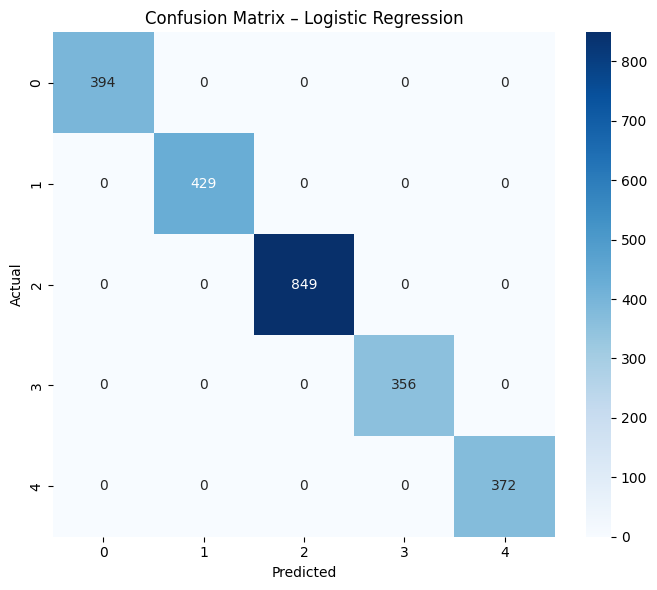

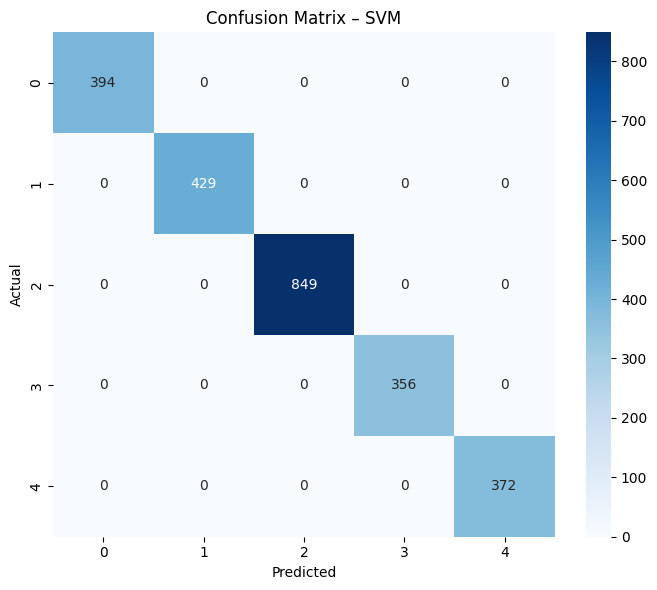

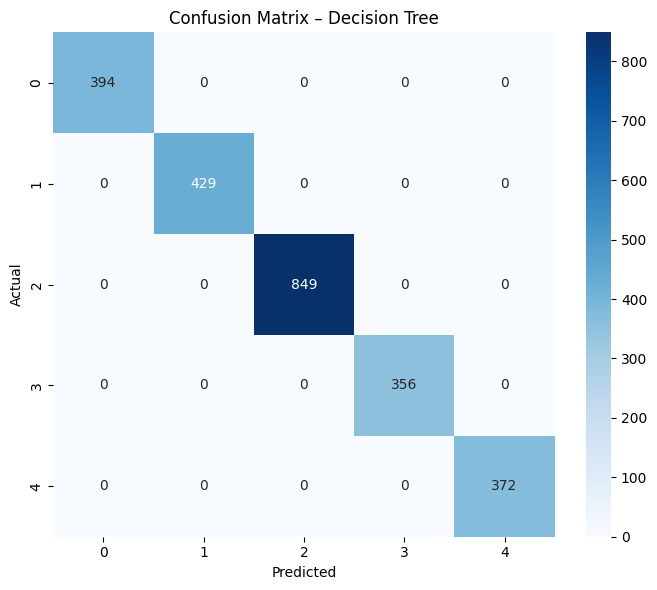

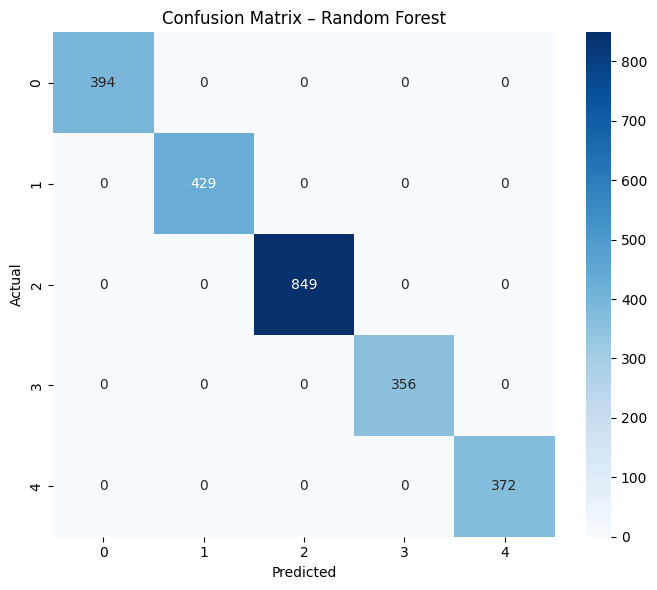

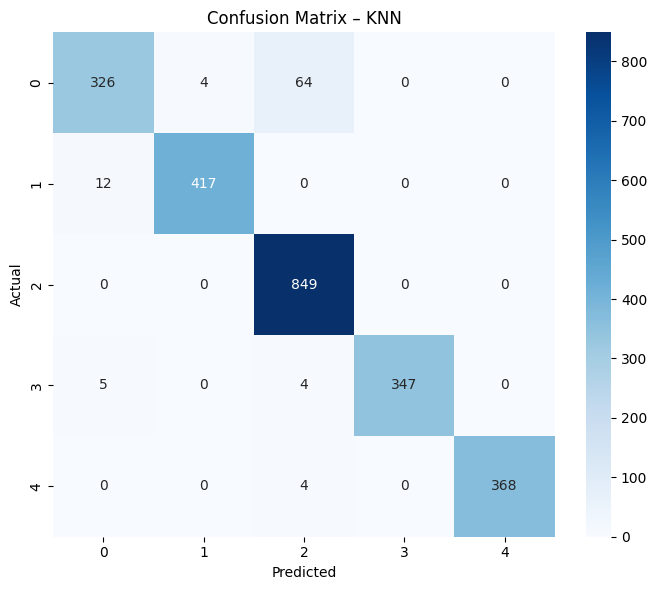

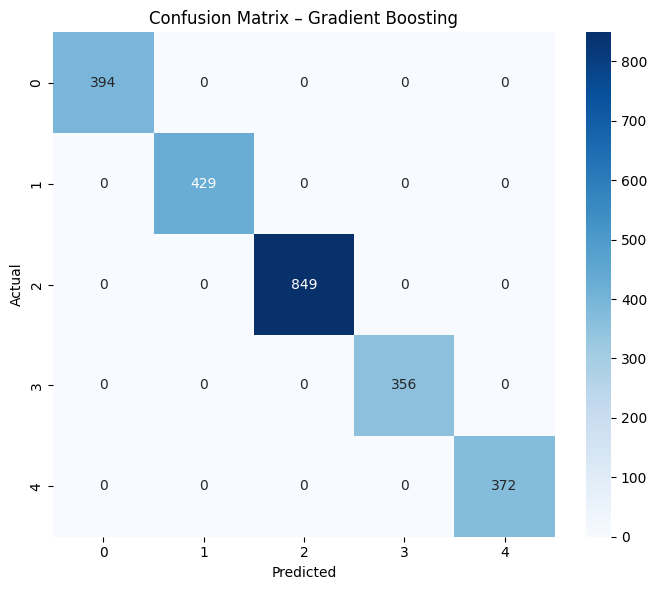

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_confusion_matrix(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(7,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix – {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.savefig(f"results/cm_{model_name.replace(' ', '_').lower()}.png")
    plt.show()

for model_name, y_pred in predictions.items():
    plot_confusion_matrix(y_test, y_pred, model_name)


5. **ROC Curve Analysis:**

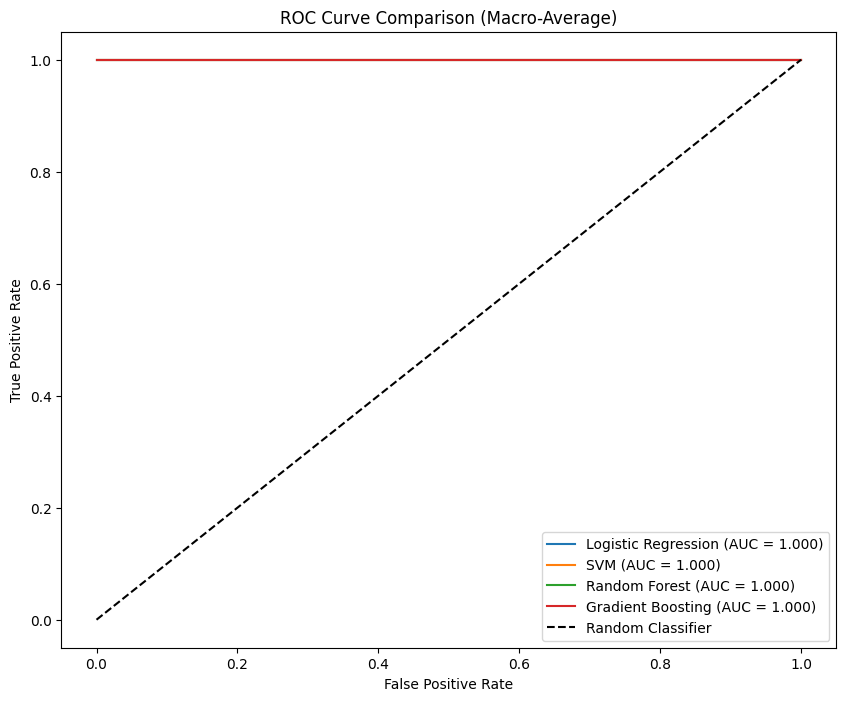

In [ ]:
probas = {
    'Logistic Regression': lr_model.predict_proba(X_test_scaled),
    'SVM': svm_model.predict_proba(X_test_scaled),
    'Random Forest': rf_model.predict_proba(X_test_scaled),
    'Gradient Boosting': gb_model.predict_proba(X_test_scaled)
}
from sklearn.preprocessing import label_binarize

n_classes = len(np.unique(y_test))
y_test_bin = label_binarize(y_test, classes=np.unique(y_test))

def compute_macro_roc(y_true_bin, y_proba, n_classes):
    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_proba[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
    mean_tpr = np.zeros_like(all_fpr)

    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])

    mean_tpr /= n_classes
    macro_auc = auc(all_fpr, mean_tpr)

    return all_fpr, mean_tpr, macro_auc

plt.figure(figsize=(10,8))

for model_name, y_proba in probas.items():
    fpr, tpr, auc_score = compute_macro_roc(y_test_bin, y_proba, n_classes)
    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {auc_score:.3f})")

plt.plot([0,1], [0,1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison (Macro-Average)')
plt.legend()
plt.savefig("results/roc_curves_all.png")
plt.show()


6. **Hyperparameter Tuning (GridSearchCV):**

In [ ]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=5,
    scoring='f1_weighted',
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train_scaled, y_train)

best_params = grid_search.best_params_
best_score = grid_search.best_score_

best_params, best_score


Fitting 5 folds for each of 81 candidates, totalling 405 fits


({'max_depth': 10,
  'min_samples_leaf': 1,
  'min_samples_split': 2,
  'n_estimators': 50},
 np.float64(1.0))

7. **Best Model Selection:**

In [ ]:
best_rf = RandomForestClassifier(**best_params, random_state=42)
best_rf.fit(X_train_scaled, y_train)

y_pred_tuned = best_rf.predict(X_test_scaled)
tuned_metrics = evaluate_model(y_test, y_pred_tuned)
tuned_metrics



{'Accuracy': 1.0, 'Precision': 1.0, 'Recall': 1.0, 'F1-Score': 1.0}

8. **Evaluation After Tuning:**

In [ ]:
comparison_df = pd.DataFrame([
    results_df.loc['Random Forest'],
    pd.Series(tuned_metrics, name='Random Forest (Tuned)')
])

comparison_df.round(4)
((comparison_df.iloc[1] - comparison_df.iloc[0]) / comparison_df.iloc[0]) * 100


,0
Accuracy,0.0
Precision,0.0
Recall,0.0
F1-Score,0.0


9. **Model Interpretability (SHAP):**

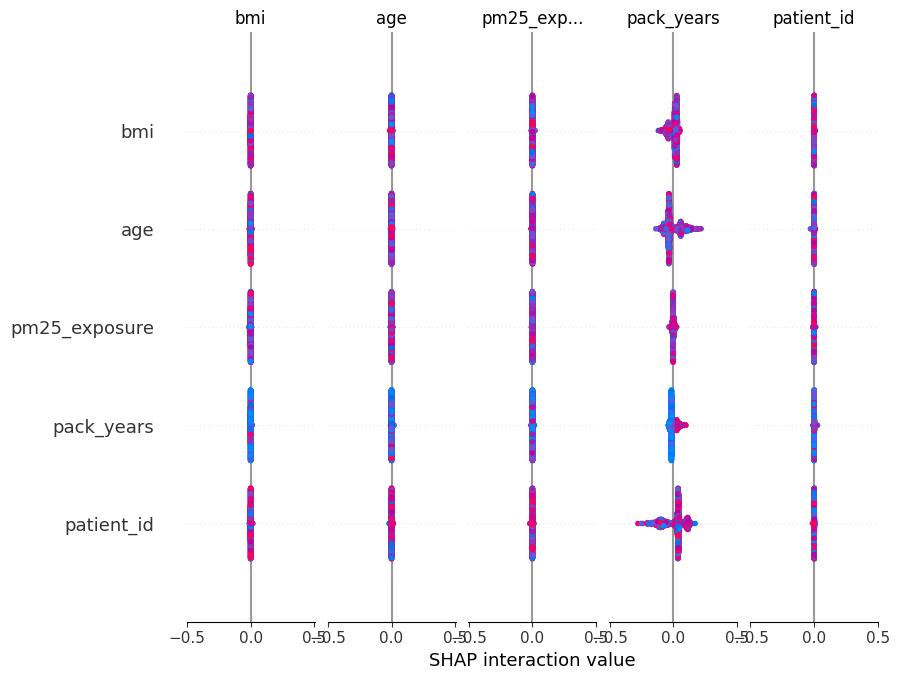

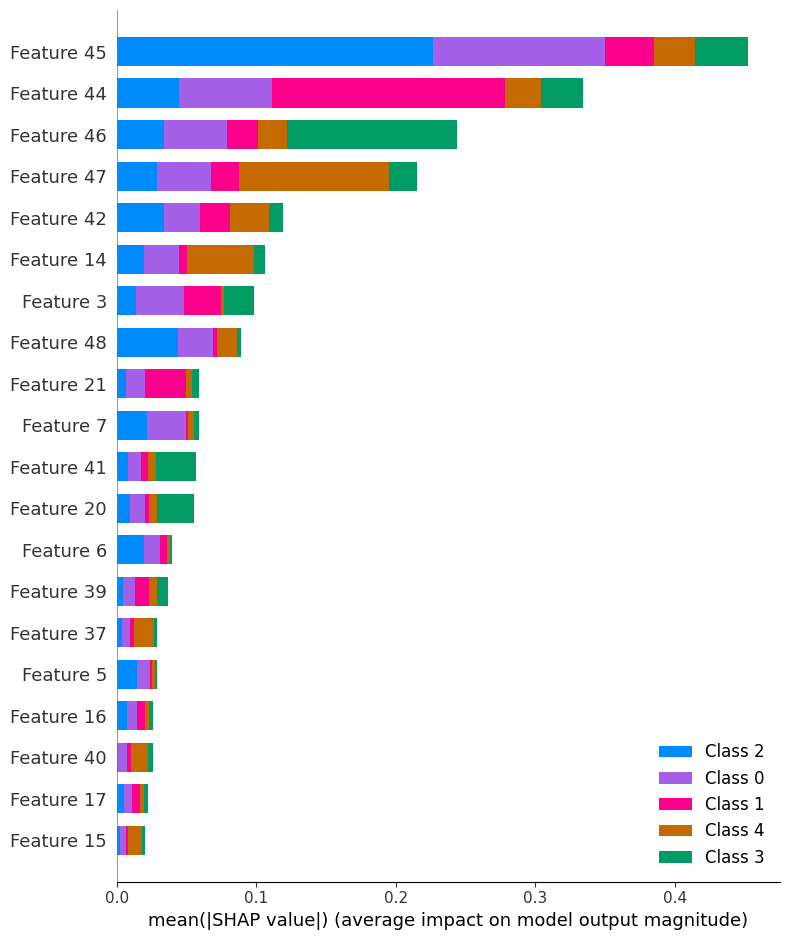

<Figure size 640x480 with 0 Axes>

In [ ]:
import shap
shap.initjs()
explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_test_scaled)
shap.summary_plot(shap_values, X_test_scaled, feature_names=X.columns)
plt.savefig("results/shap_summary.png")
shap.summary_plot(shap_values, X_test_scaled, plot_type="bar")
plt.savefig("results/shap_importance.png")


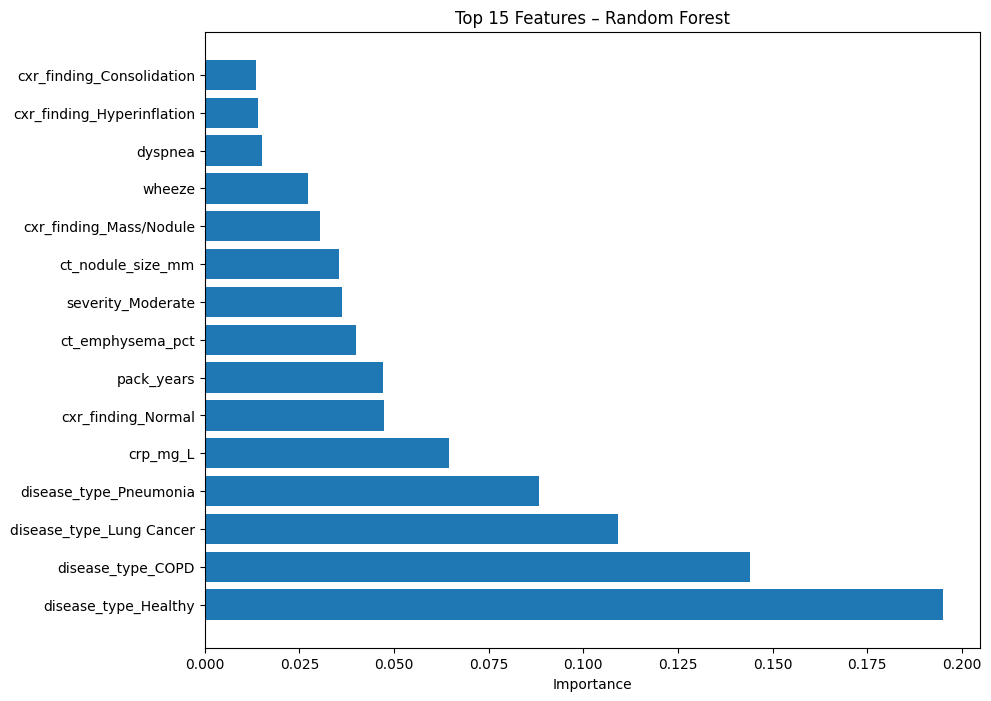

In [ ]:
feature_df = pd.DataFrame({
    'feature': X.columns,
    'importance': best_rf.feature_importances_
}).sort_values(by='importance', ascending=False)
plt.figure(figsize=(10,8))
plt.barh(feature_df['feature'][:15], feature_df['importance'][:15])
plt.xlabel('Importance')
plt.title('Top 15 Features – Random Forest')
plt.savefig("results/feature_importance.png")
plt.show()


In [ ]:
feature_df.to_csv("results/feature_importance.csv", index=False)
comparison_df.to_csv("results/tuning_comparison.csv")
joblib.dump(best_rf, "models/random_forest_tuned.pkl")


['models/random_forest_tuned.pkl']